In [1]:
import sys
from scipy import sparse
import numpy as np
import matplotlib.pyplot as plt
import os
from astropy.io import fits
import scipy.ndimage
from astropy import units as u

from scalesETC.scales import *
from scalesETC.widgets import *
from scalesETC.targs import *




%load_ext autoreload
%autoreload 2

In [2]:
scalesmode = mode_select()
guidestar = gs_select()
scalesmode #use the dropdown to select your mode!

Dropdown(description='Mode:', options=('Low-Res KLM: 2.0-5.2', 'Low-Res K: 1.95-2.45', 'Med-Res K: 1.95-2.45',…

In [3]:
sim = SCALES(scalesmode,guidestar,fullfr=True)

In [4]:
nexps = 1 #total frames to simulate
int_time = 3600 #integration time in seconds per frame

## Let's pass the ETC a scene!

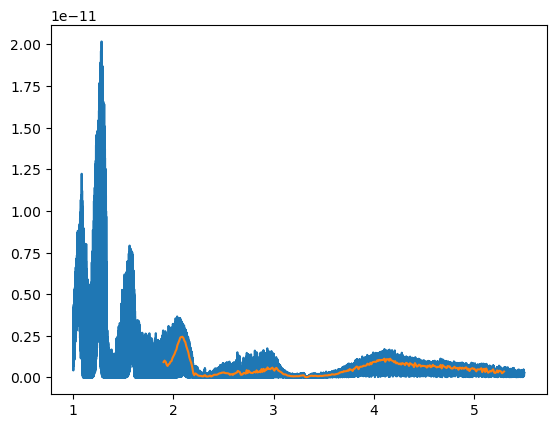

/Users/stephsallum/Sallum Group Dropbox/Steph Sallum/scalesETC_dev/scalesETC/targs.py:238: RuntimeWarning: invalid value encountered in divide
  snrcube = signal_cube/np.sqrt(signal_cube+bkg_cube)


In [9]:
plan = sonora_planet(T_p=1000,sg=100,rp=1.6,d=20.0,Kmag=9.9) #set Kmag, Lmag, OR Mmag to re-normalize your planet

scene_lowres = np.zeros([len(sim.plams),108,108]) #set up a perfect datacube to pass to the simulator (108x108 for low-res, 18x17 for med-res)
scene_lowres[:,54,54]=plan.resample(sim.plams) #add your planet to your desired pixel in the FOV

#let's check out a plot of the input spectra
plt.plot(plan.x,plan.y) #spectrally-oversampled
plt.plot(sim.plams,scene_lowres[:,54,54]) #downsampled to the input resolution expected by the simulator
plt.show()

scene_lowres=scene_lowres*u.erg/u.cm/u.cm/u.s/u.um

img_seq, IFScube_seq, rlams = sim.image_and_cube(cube=scene_lowres,nexps=nexps,dit=int_time,shot_off=False,bkgsub=True)
SNRcube, SNRlist, rlams = sim.point_snr_cube(cube=scene_lowres,nexps=nexps,dit=int_time)

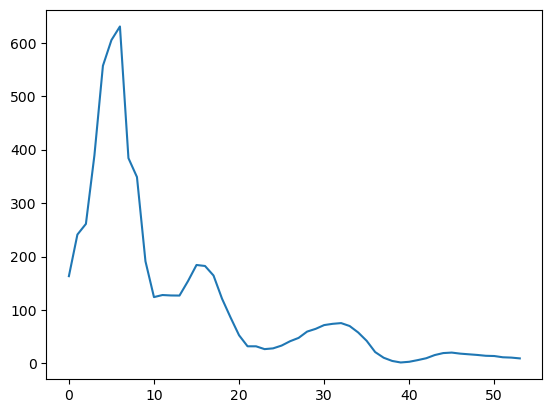

In [10]:
plt.plot(range(54),SNRcube[:,54,54])
plt.show()

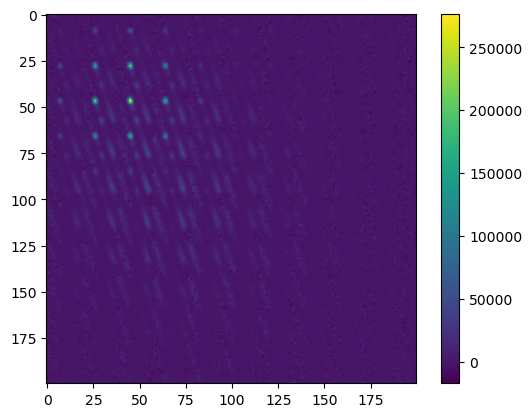

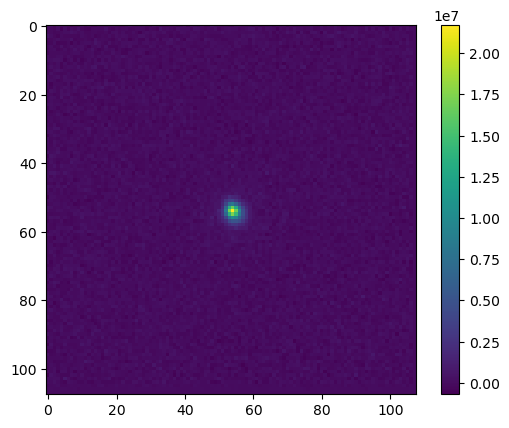

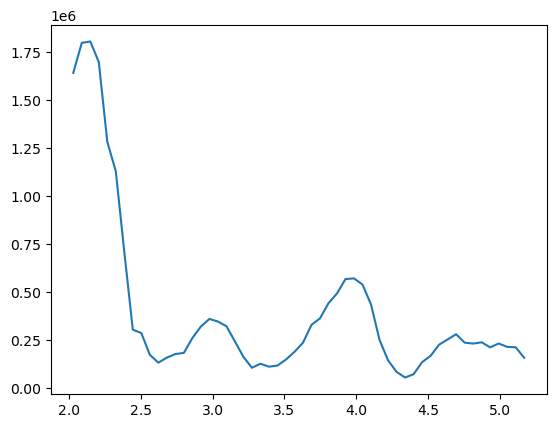

In [11]:
plt.imshow(img_seq[0,1000:1200,1000:1200])
plt.colorbar()
plt.show()

plt.imshow(np.sum(IFScube_seq[0],axis=0))
plt.colorbar()
plt.show()

plt.plot(rlams,IFScube_seq[0,:,54,54])
plt.show()

## We can also pass it a single target and it will make the scene instead!

In [12]:
img_seq, IFScube_seq, rlams = sim.image_and_cube(targ=plan,nexps=nexps,dit=int_time,shot_off=False)
SNRcube, SNRlist, rlams = sim.point_snr_cube(targ=plan,nexps=nexps,dit=int_time)